In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rc('pdf', fonttype=42)


## Identifying genes with widespread, large transcriptional effect in Perturb-seq data (K562)

From Replogle, J. M., Saunders, R. A., Pogson, A. N., Hussmann, J. A., Lenail, A., Guna, A., Mascibroda, L., Wagner, E. J., Adelman, K., Lithwick-Yanai, G., Iremadze, N., Oberstrass, F., Lipson, D., Bonnar, J. L., Jost, M., Norman, T. M., & Weissman, J. S. (2022). Mapping information-rich genotype-phenotype landscapes with genome-scale Perturb-seq. Cell, 185(14), 2559–2575.e28. https://doi.org/10.1016/j.cell.2022.05.013

Looking at the day 8 K562 data, since this library includes expressed genes that are nonessential. Uses dCas9-KRAB

Library design: "For the K562 day 8 genome-scale experiment, we targeted (i) genes expressed in K562 cells (ii) transcription factors as detailed in Lambert et al. (2018) (iii) Cancer Dependency Map common essential genes as defined in 20Q1 (iv) non-targeting control sgRNAs accounting for 5% of the total library. To define expressed genes in K562 cells, we used a combination of bulk RNA-seq data from ENCODE (https://www.encodeproject.org/files/ENCFF717EVE/) and 10x Genomics 3’ single-cell RNA-seq data (https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE146194), selecting a set of genes accounting for ~99% of aligned reads in both datasets"

This screen is combinatorial: "To minimize library size while maximizing knockdown, multiplexed CRISPRi libraries were constructed which targeted each gene with two unique sgRNAs expressed from tandem U6 expression cassettes in a single lentiviral vector"


Number of DEGs (Mann-Whitney) will be higher for perturbations that have a widespread transcriptional effect. The energy test column is also relevant because a significant p-value indicates that the transcriptional changes caused by the perturbation are significantly different than the transcriptional changes across controls. In other words, this gene has a significant impact on the cell.

This dataset includes both esesntial and nonessential genes, since the data is collected before the viability phenotype manifests

In [2]:
perturbseq_description=pd.read_excel("../data/NIHMS1812939-supplement-12.xlsx",sheet_name="description")
perturbseq_description

,column,description
0,genetic perturbation,Identity of the genetic perturbation (sgRNA pa...
1,mean UMI count,Mean UMI count for cells bearing the genetic p...
2,number of cells (unfiltered),Number of cells bearing the genetic perturbati...
3,number of cells (filtered),Number of cells bearing the genetic perturbati...
4,target expression,Expression of the target gene in control cells.
5,fold knockdown,Fold knockdown of the target gene.
6,percent knockdown,"Percent knockdown of the target genes, where n..."
7,core_control,Controls that were identified as core controls...
8,mean leverage score,Mean leverage score across all cells bearing t...
9,std of leverage score,Standard deviation of the leverage score acros...


In [3]:
perturbseq=pd.read_excel("../data/NIHMS1812939-supplement-12.xlsx",sheet_name="TabA_K562_day8_summary_stat")
perturbseq["gene"]=perturbseq["genetic perturbation"].apply(lambda st: st[st.find("_")+1:st.find("_",st.find("_")+1)])
perturbseq.sort_values(by="gene")

,genetic perturbation,mean UMI count,number of cells (unfiltered),number of cells (filtered),target expression,fold knockdown,percent knockdown,core_control,mean leverage score,std of leverage score,energy test (p-value),Number of DEGs (anderson-darling),Number of DEGs (Mann-Whitney),Z-scored number of UMIs,Fraction of mitochondrially encoded RNA,Fraction of TE RNA,Z-scored CIN score,gene
0,0_A1BG_P1_ENSG00000121410,11648.256836,246,237.0,0.171285,0.023274,-0.976726,False,0.264768,1.137824,0.017798,3,4,0.088383,0.118743,0.013627,NaN,A1BG
2428,1_A1BG_P2_ENSG00000121410,11147.025391,158,150.0,0.171285,0.643898,-0.356102,False,0.265252,1.213104,0.213079,0,0,0.024977,0.116737,0.013366,0.511523,A1BG
3528,2_AAAS_P1P2_ENSG00000094914,10828.444336,432,411.0,0.385826,0.088665,-0.911335,False,0.308258,1.031860,0.036196,2,1,-0.077938,0.118631,0.013576,0.261394,AAAS
4626,3_AACS_P1P2_ENSG00000081760,11051.574219,185,176.0,0.140473,0.000000,-1.000000,False,0.266283,0.906287,0.000700,97,67,-0.063821,0.119334,0.014559,0.075130,AACS
6839,5_AAGAB_P1P2_ENSG00000103591,12658.566406,99,99.0,0.298476,0.060795,-0.939205,False,0.212161,0.871943,0.002900,9,5,0.318073,0.119352,0.013457,-0.505964,AAGAB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,10922_non-targeting_non-targeting_non-targeting,10936.930664,216,NaN,NaN,NaN,NaN,False,0.389518,1.040482,0.000100,199,124,-0.158095,0.122694,0.013988,-1.027722,non-targeting
1018,10921_non-targeting_non-targeting_non-targeting,11468.962891,109,107.0,NaN,NaN,NaN,True,-0.002399,0.922707,0.294371,0,0,0.123575,0.120272,0.013592,-0.821745,non-targeting
1017,10920_non-targeting_non-targeting_non-targeting,11607.087891,159,145.0,NaN,NaN,NaN,True,-0.035476,0.936956,0.081492,0,0,0.109179,0.118690,0.013662,0.116786,non-targeting
1026,10929_non-targeting_non-targeting_non-targeting,11001.290039,193,NaN,NaN,NaN,NaN,False,0.329341,1.203672,0.039996,0,0,-0.096986,0.117117,0.013847,1.269882,non-targeting


The genes that we want to pick meet the following criteria across ALL possible perturbations:
1. energy distance test p<0.001 (reflect significant global transcriptional effect, according to alpha set in figure 2) 
2. more than 50 differentially expressed genes according to the anderson-darling test (cutoff for "Strong" perturbations established in publication)


In [4]:
#get rid of non-targeting controls
perturbseq= perturbseq[perturbseq["gene"]!="non-targeting"].reset_index(drop=True).copy()
perturbseq["max_pval_gene"]= perturbseq.groupby('gene')["energy test (p-value)"].transform('max')
perturbseq["min_deg_gene"]= perturbseq.groupby('gene')["Number of DEGs (anderson-darling)"].transform('min')

In [5]:
#subsetting the perturbations that are highly expressed and have  effect on global transcription 
perturbseq_higheffect= perturbseq[(perturbseq["max_pval_gene"]<0.001)&(perturbseq["min_deg_gene"]>50)].copy().reset_index(drop=True)
high_effect_genes= perturbseq_higheffect["gene"].unique()
len(high_effect_genes)

1866


All genes have at least 25 cells that passed our quality filters and an on-target knockdown, if measured, of at least 30% (i.e. the target of perturbation was either knocked down by at least 30% or was not detected, a broad attempt to remove non-functional perturbations).


From this data, we identify genes that have a significant transcriptional effect when perturbed. This list needs to be filtered to exclude essential and lowly expressed genes.

In [6]:
print("percent of genes in Replogle 2022 that meet their definition of 'strong' perturbation effect:")
print(round(100*len(high_effect_genes)/len(perturbseq["gene"].unique()),2))

percent of genes in Replogle 2022 that meet their definition of 'strong' perturbation effect:
18.91


## Evaluating targets with DepMap data

In [7]:
GEX_data=pd.read_csv("../data/DepMap2026Q1_OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")
GEX_data_T=GEX_data.set_index("ModelID").T.reset_index()
GEX_data_T=GEX_data_T[5:len(GEX_data_T)]
GEX_data_T["gene"]=GEX_data_T["index"].apply(lambda x: x.split(" (")[0])
GEX_data_T["median across cell lines"] = GEX_data_T[[col for col in GEX_data_T.columns if 'ACH' in col]].median(axis=1)
gene_to_expression=GEX_data_T.set_index("gene").to_dict()["median across cell lines"]

/var/folders/8f/5qtrvzqs2wx80q61vjbgwly80000gp/T/ipykernel_15818/2318866264.py:6: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  gene_to_expression=GEX_data_T.set_index("gene").to_dict()["median across cell lines"]


In [8]:
essentiality_data=pd.read_csv("../data/DepMap2026Q1_CRISPRGeneEffect.csv")
essentiality_data_T=essentiality_data.set_index("Unnamed: 0").T.reset_index()
essentiality_data_T["gene"]=essentiality_data_T["index"].apply(lambda x: x.split(" (")[0])
essentiality_data_T["Viability effect"]=essentiality_data_T[[col for col in essentiality_data_T.columns if 'ACH' in col]].median(axis=1)
essentiality_data_T

Unnamed: 0,index,ACH-000029,ACH-000030,ACH-000074,ACH-000090,ACH-000093,ACH-000103,ACH-000118,ACH-000133,ACH-000155,...,ACH-002508,ACH-002531,ACH-002535,ACH-002659,ACH-002688,ACH-002693,ACH-003178,ACH-003180,gene,Viability effect
0,A1BG (1),0.000151,0.169029,-0.087069,0.205441,-0.133302,-0.303846,0.039836,0.019387,0.105143,...,-0.047849,0.022499,-0.038441,-0.070679,0.223599,-0.025142,-0.142453,0.117258,A1BG,0.008099
1,A1CF (29974),0.000541,-0.182773,-0.054984,-0.138211,0.086477,0.072831,-0.040849,-0.017632,-0.171592,...,-0.024377,-0.020226,-0.009642,-0.098119,0.050004,-0.191375,-0.013497,-0.139599,A1CF,-0.013031
2,A2M (2),-0.046740,-0.023095,0.211763,-0.140932,-0.224933,-0.104622,-0.085762,0.089447,-0.075428,...,0.112366,-0.052043,0.106756,-0.091000,-0.002048,-0.124223,-0.007539,0.058613,A2M,0.000943
3,A2ML1 (144568),0.040447,0.068845,0.421891,-0.139838,0.024604,0.067485,0.052211,0.187875,-0.072287,...,0.091062,0.093984,0.078958,0.315522,0.267831,0.151720,0.039409,-0.001162,A2ML1,0.093529
4,A3GALT2 (127550),-0.188685,-0.037532,0.013034,-0.036163,0.267048,-0.028190,0.006783,-0.066664,0.027397,...,-0.198445,-0.092022,-0.090384,0.020725,0.043235,0.085021,-0.039885,-0.028189,A3GALT2,-0.050610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18526,RGPD2 (729857),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RGPD2,0.029613
18527,SMIM10L3 (122526779),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMIM10L3,-0.188836
18528,TPRX2 (503627),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TPRX2,-0.279987
18529,TTLL13 (440307),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TTLL13,-0.316684


In [9]:
merged_DepMap_data=essentiality_data_T.copy()
merged_DepMap_data=merged_DepMap_data[merged_DepMap_data["gene"].isin(gene_to_expression.keys())]
merged_DepMap_data["Expression"]=merged_DepMap_data["gene"].apply(lambda x: gene_to_expression[x])
merged_DepMap_data=merged_DepMap_data[["gene","Viability effect","Expression"]].reset_index(drop=True)
merged_DepMap_data

Unnamed: 0,gene,Viability effect,Expression
0,A1BG,0.008099,2.533728
1,A1CF,-0.013031,0.011254
2,A2M,0.000943,0.231737
3,A2ML1,0.093529,0.008692
4,A3GALT2,-0.050610,0.000000
...,...,...,...
18458,RGPD2,0.029613,0.361805
18459,SMIM10L3,-0.188836,0.000000
18460,TPRX2,-0.279987,0.000000
18461,TTLL13,-0.316684,0.094571


In [10]:
#filter to genes with large transcriptional effect, Replogle 2022
merged_DepMap_data_higheffect=merged_DepMap_data[merged_DepMap_data["gene"].isin(high_effect_genes)]


We filtered all high-transcriptional-effect genes to those we hand-selected (with use of STRING analysis) to represent a range of functional annotations

In [11]:
functionally_distinct_genes=pd.read_csv("../data/remaining_targets_post_STRING_visual_analysis.csv",header=None,usecols=[0])[0].tolist()

In [12]:
librarytargets=merged_DepMap_data_higheffect[merged_DepMap_data_higheffect["gene"].isin(functionally_distinct_genes)]

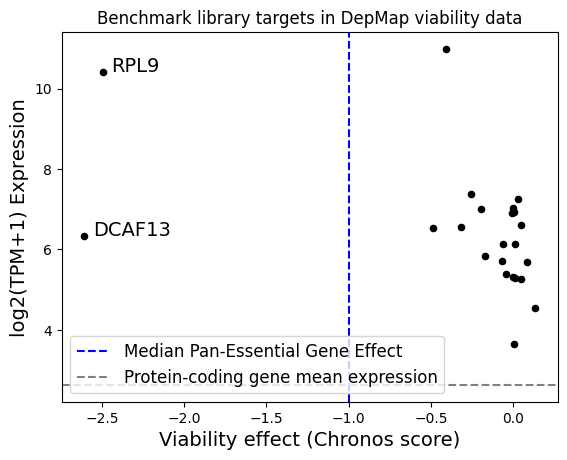

In [13]:
librarytargets.plot(x="Viability effect",y="Expression",kind="scatter",c="black")
plt.xlabel("Viability effect (Chronos score)",fontsize=14)
plt.ylabel("log2(TPM+1) Expression",fontsize=14)
plt.title("Benchmark library targets in DepMap viability data")
plt.axvline(x=-1,c="blue",linestyle="--",label="Median Pan-Essential Gene Effect")
plt.axhline(y=merged_DepMap_data["Expression"].mean(),c="grey",linestyle="--",label="Protein-coding gene mean expression")
plt.legend(loc="lower left",fontsize=12)
essentials=librarytargets[librarytargets["Viability effect"]<-1]
plt.text(x=essentials["Viability effect"].tolist()[0]+0.05,y=essentials["Expression"].tolist()[0],s=essentials["gene"].tolist()[0],fontsize=14)
plt.text(x=essentials["Viability effect"].tolist()[1]+0.05,y=essentials["Expression"].tolist()[1],s=essentials["gene"].tolist()[1],fontsize=14)
plt.savefig("../figures/benchmarklibrary_targets_DepMapinfo.pdf",dpi=600, bbox_inches="tight")